In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
robust_eval_epsilons = np.array([1.0, 0.995, 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91, 0.9, 0.875, 0.85, 0.825, 0.8, 0.75, 0.5, 0.25, 0.0])
hs = [0, 1, 2, 3, 5, 10, 15, 25, 35, 50, 75, 100, 150]

In [3]:
epsilons = np.linspace(0, 1, 21)
stage_labels = [fr"Stage {stage} ($\epsilon={round(epsilons[stage-1], 3)})$" for stage in range(1, 22)]
ticklabels = ['Random'] + stage_labels

In [4]:
h000 = pd.read_csv("h000/results/evaluation.csv")
h001 = pd.read_csv("h001/results/evaluation.csv")
h002 = pd.read_csv("h002/results/evaluation.csv")
h003 = pd.read_csv("h003/results/evaluation.csv")
h005 = pd.read_csv("h005/results/evaluation.csv")
h010 = pd.read_csv("h010/results/evaluation.csv")
h015 = pd.read_csv("h015/results/evaluation.csv")
h025 = pd.read_csv("h025/results/evaluation.csv")
h035 = pd.read_csv("h035/results/evaluation.csv")
h050 = pd.read_csv("h050/results/evaluation.csv")
h075 = pd.read_csv("h075/results/evaluation.csv")
h100 = pd.read_csv("h100/results/evaluation.csv")
h150 = pd.read_csv("h150/results/evaluation.csv")

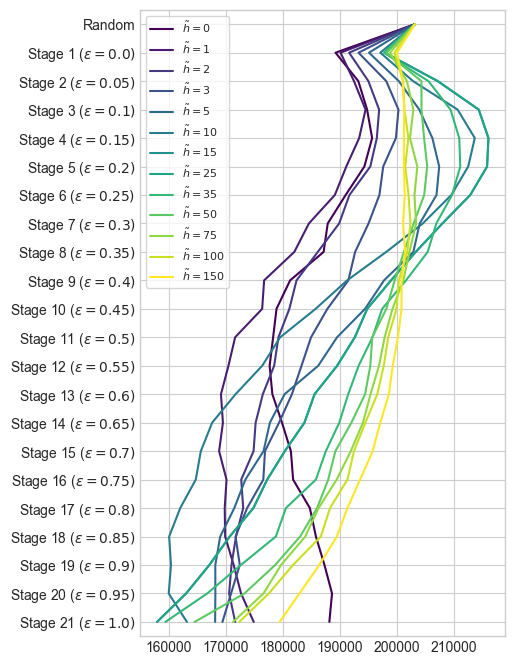

In [5]:
fig, ax = plt.subplots(1, figsize=(5.25, 6.75))
cmap = plt.colormaps['viridis']
steps = np.linspace(0, 1, 13)
ax.plot(h000.median(), range(22), c=cmap(steps[0]), label=r"$\tilde{h} = 0$")
ax.plot(h001.median(), range(22), c=cmap(steps[1]), label=r"$\tilde{h} = 1$")
ax.plot(h002.median(), range(22), c=cmap(steps[2]), label=r"$\tilde{h} = 2$")
ax.plot(h003.median(), range(22), c=cmap(steps[3]), label=r"$\tilde{h} = 3$")
ax.plot(h005.median(), range(22), c=cmap(steps[4]), label=r"$\tilde{h} = 5$")
ax.plot(h010.median(), range(22), c=cmap(steps[5]), label=r"$\tilde{h} = 10$")
ax.plot(h015.median(), range(22), c=cmap(steps[6]), label=r"$\tilde{h} = 15$")
ax.plot(h025.median(), range(22), c=cmap(steps[7]), label=r"$\tilde{h} = 25$")
ax.plot(h035.median(), range(22), c=cmap(steps[8]), label=r"$\tilde{h} = 35$")
ax.plot(h050.median(), range(22), c=cmap(steps[9]), label=r"$\tilde{h} = 50$")
ax.plot(h075.median(), range(22), c=cmap(steps[10]), label=r"$\tilde{h} = 75$")
ax.plot(h100.median(), range(22), c=cmap(steps[11]), label=r"$\tilde{h} = 100$")
ax.plot(h150.median(), range(22), c=cmap(steps[12]), label=r"$\tilde{h} = 150$")
ax.set_yticks(range(22))
ax.set_yticklabels(ticklabels)
ax.set_ylim(-0.5, 21.5)
ax.axes.yaxis.set_inverted(True)
ax.legend(frameon=True, fontsize=8)
plt.tight_layout()
fig.savefig("../../../plt/pruning_experiment_training_curves.pdf")

In [6]:
rh000 = pd.read_csv("h000/results/robust_evaluation.csv")
rh001 = pd.read_csv("h001/results/robust_evaluation.csv")
rh002 = pd.read_csv("h002/results/robust_evaluation.csv")
rh003 = pd.read_csv("h003/results/robust_evaluation.csv")
rh005 = pd.read_csv("h005/results/robust_evaluation.csv")
rh010 = pd.read_csv("h010/results/robust_evaluation.csv")
rh015 = pd.read_csv("h015/results/robust_evaluation.csv")
rh025 = pd.read_csv("h025/results/robust_evaluation.csv")
rh035 = pd.read_csv("h035/results/robust_evaluation.csv")
rh050 = pd.read_csv("h050/results/robust_evaluation.csv")
rh075 = pd.read_csv("h075/results/robust_evaluation.csv")
rh100 = pd.read_csv("h100/results/robust_evaluation.csv")
rh150 = pd.read_csv("h150/results/robust_evaluation.csv")

In [7]:
footprint = pd.read_csv("footprint.csv")

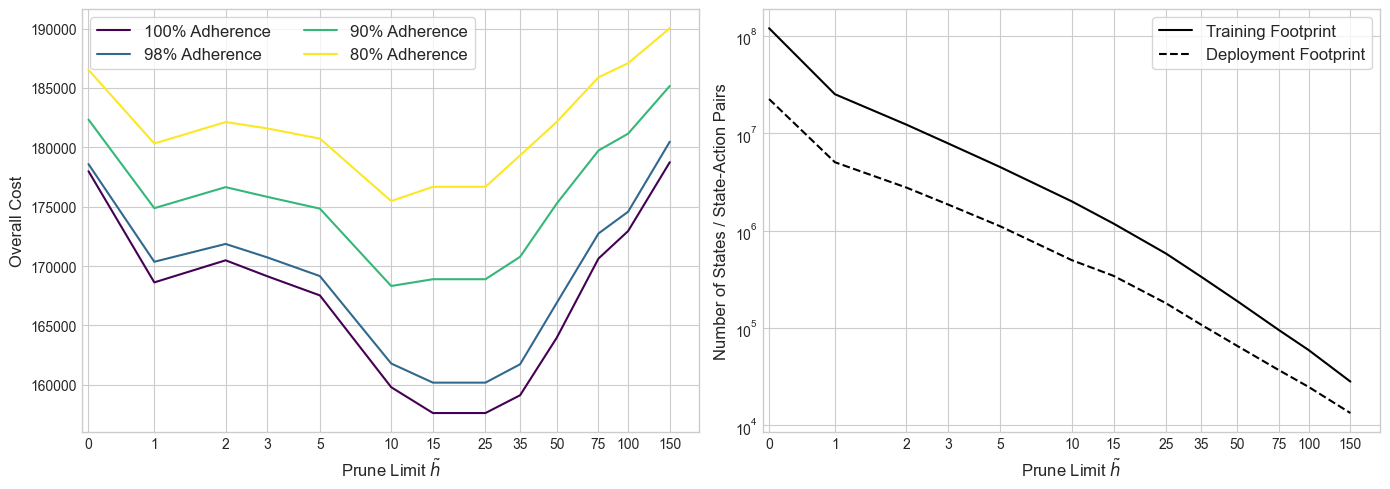

In [8]:
fig, axarr = plt.subplots(1, 2, figsize=(14, 5))
axarr[0].plot(hs, [d['Stage 0'].median() for d in [rh000, rh001, rh002, rh003, rh005, rh010, rh015, rh025, rh035, rh050, rh075, rh100, rh150]], c=cmap(0.0), label="100% Adherence")
axarr[0].plot(hs, [d['Stage 3'].median() for d in [rh000, rh001, rh002, rh003, rh005, rh010, rh015, rh025, rh035, rh050, rh075, rh100, rh150]], c=cmap(0.333), label="98% Adherence")
axarr[0].plot(hs, [d['Stage 11'].median() for d in [rh000, rh001, rh002, rh003, rh005, rh010, rh015, rh025, rh035, rh050, rh075, rh100, rh150]], c=cmap(0.666), label="90% Adherence")
axarr[0].plot(hs, [d['Stage 15'].median() for d in [rh000, rh001, rh002, rh003, rh005, rh010, rh015, rh025, rh035, rh050, rh075, rh100, rh150]], c=cmap(1.0), label="80% Adherence")
axarr[0].legend(ncol=2, fontsize=12, frameon=True)
axarr[0].set_xscale("symlog", linthresh=1, linscale=0.25)
axarr[0].set_xlim(-0.1, 200) 
axarr[0].set_xticks(hs)
axarr[0].set_xticklabels(hs)
axarr[0].set_xlabel(r"Prune Limit $\tilde{h}$", fontsize=12)
axarr[0].set_ylabel("Overall Cost", fontsize=12)

axarr[1].plot(hs, footprint['training'], label="Training Footprint", c='black', linestyle="solid")
axarr[1].plot(hs, footprint['deployment'], label="Deployment Footprint", c='black', linestyle="dashed")
axarr[1].set_yscale('log', base=10)
axarr[1].legend(fontsize=12, frameon=True)
axarr[1].set_xscale("symlog", linthresh=1, linscale=0.25)
axarr[1].set_xlim(-0.1, 200) 
axarr[1].set_xticks(hs)
axarr[1].set_xticklabels(hs)
axarr[1].set_xlabel(r"Prune Limit $\tilde{h}$", fontsize=12)
axarr[1].set_ylabel("Number of States / State-Action Pairs", fontsize=12)
plt.tight_layout()
fig.savefig("../../../plt/pruning_experiment.pdf")

In [19]:
rh025['Stage 0'].median()

np.float64(157628.595)

In [20]:
((rh000['Stage 11'].median() - rh000['Stage 0'].median()) / rh000['Stage 0'].median()) * 100

np.float64(2.4426535059288716)

In [22]:
((rh025['Stage 11'].median() - rh025['Stage 0'].median()) / rh025['Stage 0'].median()) * 100

np.float64(7.148328639229448)